# SmartTeaAI - Elevation-Level Price Forecasting

Trains **LSTM** and **XGBoost (core)** separately for each elevation target:
`price_high_rs`, `price_medium_rs`, `price_low_rs`.

For each elevation the better model (lower MAPE) is selected independently.
Results saved to `models/elevation_models.json`.

**Leakage rules (per elevation):**
- The target elevation's `_roll3` column is excluded (rolling mean includes current month).
- The *other two* elevation columns and all their derived features are excluded.
- `price_national_avg` and all its derivatives are excluded (weighted average of targets).
- `price_spread_high_low` and `price_vol_cross_elev` are excluded (depend on targets).


In [1]:
import os, json, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import joblib
import xgboost as xgb
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime

warnings.filterwarnings('ignore')

DATA_DIR  = '../data'
MODEL_DIR = '../models'
CHART_DIR = '../data/charts'
LSTM_WINDOW = 3


In [ ]:
# Feature sets per elevation - elevation-specific lags, weather, production.
# Each set replaces national-avg lag features with the elevation's own lags,
# and uses the matching elevation weather/temp/production columns.
ELEVATION_CONFIGS = {
    'high': {
        'target': 'price_high_rs',
        'features': [
            'price_high_rs_lag1', 'price_high_rs_lag3',
            'rainfall_mm_high', 'rainfall_mm_high_lag1', 'rainfall_mm_high_lag2',
            'avg_temp_c_high',
            'usd_lkr_avg', 'fx_change_pct',
            'oil_price',
            'mombasa_usd_kg',
            'export_black_qty_kg', 'export_black_fob_avg',
            'prod_high_kg',
            'month', 'is_peak_season',
            'sentiment_score',
            'is_post_crisis',
        ],
    },
    'medium': {
        'target': 'price_medium_rs',
        'features': [
            'price_medium_rs_lag1', 'price_medium_rs_lag3',
            'rainfall_mm_medium', 'rainfall_mm_medium_lag1', 'rainfall_mm_medium_lag2',
            'avg_temp_c_medium',
            'usd_lkr_avg', 'fx_change_pct',
            'oil_price',
            'mombasa_usd_kg',
            'export_black_qty_kg', 'export_black_fob_avg',
            'prod_medium_kg',
            'month', 'is_peak_season',
            'sentiment_score',
            'is_post_crisis',
        ],
    },
    'low': {
        'target': 'price_low_rs',
        'features': [
            'price_low_rs_lag1', 'price_low_rs_lag3',
            'rainfall_mm_low', 'rainfall_mm_low_lag1', 'rainfall_mm_low_lag2',
            'avg_temp_c_low',
            'usd_lkr_avg', 'fx_change_pct',
            'oil_price',
            'mombasa_usd_kg',
            'export_black_qty_kg', 'export_black_fob_avg',
            'prod_low_kg',
            'month', 'is_peak_season',
            'sentiment_score',
            'is_post_crisis',
        ],
    },
}


In [3]:
train_df = pd.read_csv(f'{DATA_DIR}/train_set.csv')
val_df   = pd.read_csv(f'{DATA_DIR}/val_set.csv')
test_df  = pd.read_csv(f'{DATA_DIR}/test_set.csv')

for df in [train_df, val_df, test_df]:
    df['is_post_crisis'] = (pd.to_datetime(df['year_month']) >= '2022-04-01').astype(int)

print(f'Train: {len(train_df)} rows  ({train_df["year_month"].min()} -> {train_df["year_month"].max()})')
print(f'Val  : {len(val_df)} rows  ({val_df["year_month"].min()} -> {val_df["year_month"].max()})')
print(f'Test : {len(test_df)} rows  ({test_df["year_month"].min()} -> {test_df["year_month"].max()})')


Train: 94 rows  (2015-04 -> 2023-01)
Val  : 20 rows  (2023-02 -> 2024-09)
Test : 22 rows  (2024-10 -> 2026-07)


In [4]:
def compute_metrics(y_true, y_pred, model_name):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mae  = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred)**2)))
    mape = float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    r2   = float(1 - ss_res / ss_tot)
    return {'Model': model_name, 'MAE': round(mae,2), 'RMSE': round(rmse,2),
            'MAPE(%)': round(mape,4), 'R2': round(r2,4)}


## Training Loop - LSTM + XGBoost per Elevation

For each elevation the cell below:
1. Filters features to the elevation-safe set
2. Trains XGBoost (core) with early stopping
3. Trains LSTM (same architecture as national model)
4. Evaluates both on test set
5. Selects the winner by MAPE
6. Saves both models and the winner metadata


In [ ]:
elevation_results = {}  # elevation -> {'xgb': metrics, 'lstm': metrics, 'winner': ...}
elevation_models  = {}  # for elevation_models.json

for elev, cfg in ELEVATION_CONFIGS.items():
    TARGET   = cfg['target']
    FEATURES = [f for f in cfg['features'] if f in train_df.columns]
    missing  = [f for f in cfg['features'] if f not in train_df.columns]

    print(f'\n{"="*60}')
    print(f'ELEVATION: {elev.upper()}  |  target: {TARGET}')
    print(f'Features : {len(FEATURES)}')
    if missing:
        print(f'  Missing (skipped): {missing}')
    print(f'{"="*60}')

    y_train = train_df[TARGET].values
    y_val   = val_df[TARGET].values
    y_test  = test_df[TARGET].values

    # ── XGBoost (core equivalent for this elevation) ────────────────────────
    print(f'\n[{elev}] Training XGBoost...')
    X_tr_xgb = train_df[FEATURES].values
    X_va_xgb = val_df[FEATURES].values
    X_te_xgb = test_df[FEATURES].values

    xgb_model = xgb.XGBRegressor(
        n_estimators=1000, learning_rate=0.05, max_depth=4,
        min_child_weight=3, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0, random_state=42,
        eval_metric='rmse', early_stopping_rounds=40, verbosity=0,
    )
    xgb_model.fit(X_tr_xgb, y_train, eval_set=[(X_va_xgb, y_val)], verbose=False)
    xgb_preds   = xgb_model.predict(X_te_xgb)
    xgb_metrics = compute_metrics(y_test, xgb_preds, f'XGBoost ({elev})')
    print(f'  XGBoost  MAPE={xgb_metrics["MAPE(%)"]:.2f}%  RMSE={xgb_metrics["RMSE"]:.2f}  R2={xgb_metrics["R2"]:.4f}')

    # ── LSTM ────────────────────────────────────────────────────────────────
    print(f'[{elev}] Training LSTM...')
    all_df     = pd.concat([train_df, val_df, test_df], ignore_index=True)
    scaler     = MinMaxScaler()
    scaler.fit(train_df[FEATURES].values) # fit only on train 
    X_all_sc   = scaler.transform(all_df[FEATURES].values) # apply to everything
    y_all      = all_df[TARGET].values
    n_tr, n_va = len(train_df), len(val_df)
    W          = LSTM_WINDOW

    X_seq = np.array([X_all_sc[i:i+W] for i in range(len(X_all_sc)-W)])
    y_seq = y_all[W:]

    X_tr_seq = X_seq[:n_tr-W];          y_tr_seq = y_seq[:n_tr-W]
    X_va_seq = X_seq[n_tr-W:n_tr+n_va-W]; y_va_seq = y_seq[n_tr-W:n_tr+n_va-W]
    X_te_seq = X_seq[n_tr+n_va-W:];    y_te_seq = y_seq[n_tr+n_va-W:]

    tf.keras.backend.clear_session()
    lstm_model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(W, len(FEATURES))),
        tf.keras.layers.LSTM(64, return_sequences=True),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.LSTM(32),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(1),
    ])
    lstm_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse')

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=20, restore_best_weights=True, verbose=0
    )
    lstm_model.fit(
        X_tr_seq, y_tr_seq,
        validation_data=(X_va_seq, y_va_seq),
        epochs=200, batch_size=16,
        callbacks=[es], verbose=0,
    )
    lstm_preds   = lstm_model.predict(X_te_seq, verbose=0).flatten()
    lstm_metrics = compute_metrics(y_te_seq, lstm_preds, f'LSTM ({elev})')
    print(f'  LSTM     MAPE={lstm_metrics["MAPE(%)"]:.2f}%  RMSE={lstm_metrics["RMSE"]:.2f}  R2={lstm_metrics["R2"]:.4f}')

    # ── Select winner ───────────────────────────────────────────────────────
    if lstm_metrics['MAPE(%)'] <= xgb_metrics['MAPE(%)']:
        winner, winner_metrics = 'LSTM', lstm_metrics
    else:
        winner, winner_metrics = 'XGBoost', xgb_metrics
    print(f'  Winner   -> {winner}  (MAPE={winner_metrics["MAPE(%)"]:.2f}%)')

    # ── Save models ─────────────────────────────────────────────────────────
    # XGBoost
    xgb_file  = f'xgb_elevation_{elev}.json'
    feat_file = f'elevation_features_{elev}.json'
    xgb_model.save_model(f'{MODEL_DIR}/{xgb_file}')
    with open(f'{MODEL_DIR}/{feat_file}', 'w') as f:
        json.dump(FEATURES, f, indent=2)

    # LSTM
    lstm_file   = f'lstm_model_{elev}.keras'
    scaler_file = f'lstm_scaler_{elev}.joblib'
    meta_file   = f'lstm_meta_{elev}.json'
    lstm_model.save(f'{MODEL_DIR}/{lstm_file}')
    joblib.dump(scaler, f'{MODEL_DIR}/{scaler_file}')
    with open(f'{MODEL_DIR}/{meta_file}', 'w') as f:
        json.dump({'window': W, 'features': FEATURES, 'target': TARGET}, f, indent=2)

    print(f'  Saved: {xgb_file}, {lstm_file}')

    elevation_results[elev] = {
        'xgb':    xgb_metrics,
        'lstm':   lstm_metrics,
        'winner': winner,
    }
    elevation_models[elev] = {
        'target':          TARGET,
        'best_model':      winner,
        'mape_pct':        winner_metrics['MAPE(%)'],
        'rmse':            winner_metrics['RMSE'],
        'r2':              winner_metrics['R2'],
        'xgb_file':        xgb_file,
        'xgb_features_file': feat_file,
        'lstm_file':       lstm_file,
        'lstm_scaler_file': scaler_file,
        'lstm_meta_file':  meta_file,
        'trained_on':      datetime.now().isoformat(),
        'xgb_metrics':     xgb_metrics,
        'lstm_metrics':    lstm_metrics,
    }



ELEVATION: HIGH  |  target: price_high_rs
Features : 17

[high] Training XGBoost...
  XGBoost  MAPE=4.68%  RMSE=64.93  R2=-0.9291
[high] Training LSTM...

  LSTM     MAPE=45.59%  RMSE=495.25  R2=-111.2323
  Winner   -> XGBoost  (MAPE=4.68%)
  Saved: xgb_elevation_high.json, lstm_model_high.keras

ELEVATION: MEDIUM  |  target: price_medium_rs
Features : 17

[medium] Training XGBoost...
  XGBoost  MAPE=3.96%  RMSE=49.14  R2=-1.1801
[medium] Training LSTM...
  LSTM     MAPE=46.79%  RMSE=485.89  R2=-212.1357
  Winner   -> XGBoost  (MAPE=3.96%)
  Saved: xgb_elevation_medium.json, lstm_model_medium.keras

ELEVATION: LOW  |  target: price_low_rs
Features : 17

[low] Training XGBoost...
  XGBoost  MAPE=3.36%  RMSE=48.53  R2=-2.0381
[low] Training LSTM...
  LSTM     MAPE=49.58%  RMSE=613.49  R2=-484.4626
  Winner   -> XGBoost  (MAPE=3.36%)
  Saved: xgb_elevation_low.json, lstm_model_low.keras


In [6]:
# Summary table
print('\n' + '='*65)
print('ELEVATION MODEL SUMMARY')
print('='*65)
rows = []
for elev, res in elevation_results.items():
    rows.append({'Elevation': elev.upper(),
                 'XGBoost MAPE': f'{res["xgb"]["MAPE(%)"]:.2f}%',
                 'LSTM MAPE':    f'{res["lstm"]["MAPE(%)"]:.2f}%',
                 'Winner':       res['winner']})
print(pd.DataFrame(rows).to_string(index=False))
print('='*65)



ELEVATION MODEL SUMMARY
Elevation XGBoost MAPE LSTM MAPE  Winner
     HIGH        4.68%    45.59% XGBoost
   MEDIUM        3.96%    46.79% XGBoost
      LOW        3.36%    49.58% XGBoost


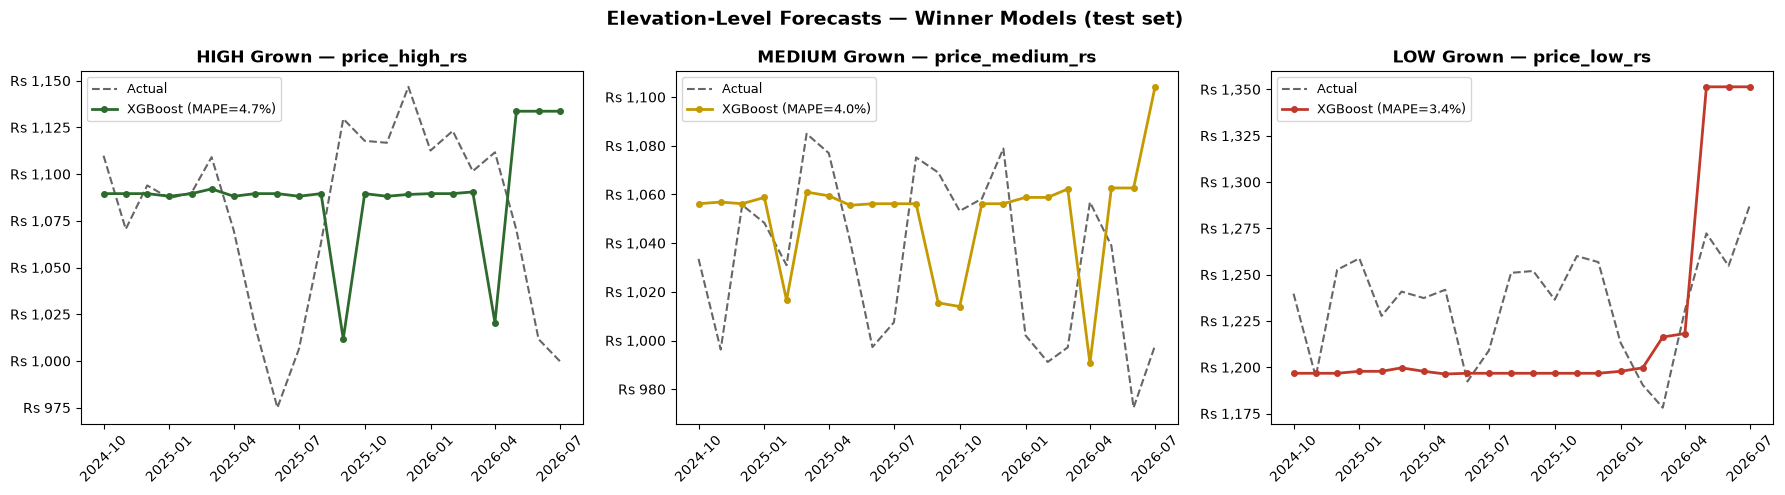

Saved: 20_elevation_forecasts.png


In [7]:
# Actual-vs-predicted chart per elevation (winner model)
test_dates = pd.to_datetime(test_df['year_month'])
elev_colors = {'high': '#2D6A2D', 'medium': '#C49A00', 'low': '#C0392B'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
for ax, (elev, res) in zip(axes, elevation_results.items()):
    TARGET = ELEVATION_CONFIGS[elev]['target']
    y_act  = test_df[TARGET].values

    # Reconstruct winner predictions from saved models
    FEATURES = [f for f in ELEVATION_CONFIGS[elev]['features'] if f in train_df.columns]
    if res['winner'] == 'XGBoost':
        m = xgb.XGBRegressor()
        m.load_model(f'{MODEL_DIR}/xgb_elevation_{elev}.json')
        preds = m.predict(test_df[FEATURES].values)
    else:
        m      = tf.keras.models.load_model(f'{MODEL_DIR}/lstm_model_{elev}.keras')
        sc     = joblib.load(f'{MODEL_DIR}/lstm_scaler_{elev}.joblib')
        all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
        X_sc   = sc.transform(all_df[FEATURES].values)
        X_seq  = np.array([X_sc[i:i+LSTM_WINDOW] for i in range(len(X_sc)-LSTM_WINDOW)])
        preds  = m.predict(X_seq[len(train_df)+len(val_df)-LSTM_WINDOW:], verbose=0).flatten()

    winner_key = 'lstm' if res['winner'] == 'LSTM' else 'xgb'
    mape = res[winner_key]['MAPE(%)']
    ax.plot(test_dates, y_act, 'k--', lw=1.5, alpha=0.6, label='Actual')
    ax.plot(test_dates, preds, color=elev_colors[elev], lw=2, marker='o', ms=4,
            label=f'{res["winner"]} (MAPE={mape:.1f}%)')
    ax.set_title(f'{elev.upper()} Grown — {TARGET}', fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rs {x:,.0f}'))
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Elevation-Level Forecasts — Winner Models (test set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/20_elevation_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 20_elevation_forecasts.png')

In [8]:
with open(f'{MODEL_DIR}/elevation_models.json', 'w') as f:
    json.dump(elevation_models, f, indent=2)

print('Saved: elevation_models.json')
print()
for elev, info in elevation_models.items():
    print(f'{elev.upper():8s}  winner={info["best_model"]:8s}  '
          f'MAPE={info["mape_pct"]:.2f}%  RMSE={info["rmse"]:.2f}')


Saved: elevation_models.json

HIGH      winner=XGBoost   MAPE=4.68%  RMSE=64.93
MEDIUM    winner=XGBoost   MAPE=3.96%  RMSE=49.14
LOW       winner=XGBoost   MAPE=3.36%  RMSE=48.53


In [9]:
for col in train_df.columns:
    print(col)

year_month
price_high_rs
price_low_rs
price_medium_rs
sales_qty_high_kg
sales_qty_low_kg
sales_qty_medium_kg
prod_high_kg
prod_low_kg
prod_medium_kg
prod_ctc_kg
prod_green_tea_kg
prod_orthodox_kg
export_black_qty_kg
export_black_fob_avg
price_high_rs_lag1
price_high_rs_lag3
price_high_rs_roll3
price_low_rs_lag1
price_low_rs_lag3
price_low_rs_roll3
price_medium_rs_lag1
price_medium_rs_lag3
price_medium_rs_roll3
month
quarter
is_peak_season
rainfall_mm_high
rainfall_mm_low
rainfall_mm_medium
avg_temp_c_high
avg_temp_c_low
avg_temp_c_medium
rainfall_mm
avg_temp_c
usd_lkr_avg
oil_price
mombasa_usd_kg
sentiment_score
price_national_avg
price_national_avg_lag1
price_national_avg_lag3
price_national_avg_roll3
price_national_avg_vol4
price_spread_high_low
price_vol_cross_elev
rainfall_mm_high_lag1
rainfall_mm_high_lag2
rainfall_mm_high_roll3
rainfall_mm_medium_lag1
rainfall_mm_medium_lag2
rainfall_mm_medium_roll3
rainfall_mm_low_lag1
rainfall_mm_low_lag2
rainfall_mm_low_roll3
rainfall_mm_lag1
